# Zomato Funnel Analytics — Exploratory Data Analysis

Advanced EDA on the synthetic Zomato-style dataset (users, restaurants, menu_items,
sessions, events, orders, order_items) generated for this project.


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
%matplotlib inline

In [5]:
USERNAME = os.getenv("DB_USERNAME")
PASSWORD = os.getenv("DB_PASSWORD")
HOST = os.getenv("DB_HOST", "localhost")
PORT = int(os.getenv("DB_PORT", 3306))
DATABASE = os.getenv("DB_NAME")

engine = create_engine(f"mysql+pymysql://{USERNAME}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}")
print("Connected to:", DATABASE)

Connected to: zomato_analytics


In [9]:
users = pd.read_sql("SELECT * FROM users", con=engine)
restaurants = pd.read_sql("SELECT * FROM restaurants", con=engine)
menu_items = pd.read_sql("SELECT * FROM menu_items", con=engine)
sessions = pd.read_sql("SELECT * FROM sessions", con=engine)
events = pd.read_sql("SELECT * FROM events", con=engine)
orders = pd.read_sql("SELECT * FROM orders", con=engine)
order_items = pd.read_sql("SELECT * FROM order_items", con=engine)


restaurants[["rating", "delivery_fee"]] = restaurants[["rating", "delivery_fee"]].astype(float)
menu_items["price"] = menu_items["price"].astype(float)
orders[["order_value", "delivery_fee", "coupon_discount"]] = orders[
    ["order_value", "delivery_fee", "coupon_discount"]
].astype(float)
order_items["price_at_purchase"] = order_items["price_at_purchase"].astype(float)

tables = {
    "users": users, "restaurants": restaurants, "menu_items": menu_items,
    "sessions": sessions, "events": events, "orders": orders, "order_items": order_items
}

for name, df in tables.items():
    print(f"{name:15s} -> {df.shape[0]:>7,} rows | {df.shape[1]} cols")

users           ->   5,000 rows | 9 cols
restaurants     ->     600 rows | 8 cols
menu_items      ->   2,920 rows | 5 cols
sessions        ->  50,000 rows | 6 cols
events          -> 172,630 rows | 9 cols
orders          ->  13,041 rows | 11 cols
order_items     ->  32,726 rows | 5 cols


In [10]:
for name, df in tables.items():
    print(f"\n{'='*50}\n{name.upper()}\n{'='*50}")
    display(df.head())
    print(df.dtypes)


USERS


,user_id,name,email,gender,age,city,signup_date,is_premium,device_type
0,1,Wriddhish Dewan,srinivasunnati@example.net,Male,55,Pune,2024-11-07,0,Android
1,2,Jai Randhawa,samarthchandra@example.org,Other,19,Jaipur,2024-09-26,1,iOS
2,3,Gabriel Sethi,rohan20@example.com,Male,40,Delhi,2025-09-23,0,Android
3,4,Maanas Maharaj,subramaniamsaumya@example.org,Male,18,Pune,2024-10-31,0,iOS
4,5,Janani Rana,vermagautami@example.org,Female,33,Chennai,2025-12-05,0,Android


user_id         int64
name              str
email             str
gender            str
age             int64
city              str
signup_date    object
is_premium      int64
device_type       str
dtype: object

RESTAURANTS


,restaurant_id,restaurant_name,city,cuisine,rating,average_cost,delivery_fee,avg_delivery_time
0,1,Domino's Pizza,Delhi,Pizza,4.3,874,20.0,37
1,2,Pizza Hut,Delhi,Pizza,3.9,751,20.0,34
2,3,Burger King,Delhi,Fast Food,4.1,453,20.0,42
3,4,KFC,Delhi,Fast Food,3.9,550,30.0,27
4,5,McDonald's,Delhi,Fast Food,4.2,601,20.0,40


restaurant_id          int64
restaurant_name          str
city                     str
cuisine                  str
rating               float64
average_cost           int64
delivery_fee         float64
avg_delivery_time      int64
dtype: object

MENU_ITEMS


...

event_id                   int64
session_id                 int64
user_id                    int64
restaurant_id            float64
event_name                   str
event_time        datetime64[us]
page_name                    str
coupon_code                  str
payment_method               str
dtype: object

ORDERS


,order_id,user_id,restaurant_id,order_time,order_value,delivery_fee,coupon_discount,payment_method,payment_status,order_status,delivery_time_minutes
0,1,1,391,2026-05-20 13:18:30,514.62,30.0,50.0,Debit Card,Failed,Failed,NaN
1,2,1,251,2026-02-22 12:06:52,1203.38,50.0,50.0,UPI,Success,Delivered,41.0
2,3,1,398,2026-06-25 12:16:23,155.86,0.0,30.0,Wallet,Success,Cancelled,NaN
3,4,1,527,2026-05-04 20:59:30,956.83,40.0,0.0,Net Banking,Success,Delivered,55.0
4,5,2,480,2026-06-20 18:50:31,442.11,30.0,0.0,UPI,Success,Delivered,26.0


order_id                          int64
user_id                           int64
restaurant_id                     int64
order_time               datetime64[us]
order_value                     float64
delivery_fee                    float64
coupon_discount                 float64
payment_method                      str
payment_status                      str
order_status                        str
delivery_time_minutes           float64
dtype: object

ORDER_ITEMS


,order_item_id,order_id,item_id,quantity,price_at_purchase
0,1,1,1926,3,141.52
1,2,1,1927,1,90.06
2,3,2,1242,2,326.90
3,4,2,1244,1,205.95
4,5,2,1245,2,57.10


order_item_id          int64
order_id               int64
item_id                int64
quantity               int64
price_at_purchase    float64
dtype: object


## Step 2: Data Quality Check

In [11]:
print("Missing values in each table:\n")
for name, df in tables.items():
    missing = df.isnull().sum().sum()
    print(f"{name}: {missing} missing values")

Missing values in each table:

users: 0 missing values
restaurants: 0 missing values
menu_items: 0 missing values
sessions: 0 missing values
events: 372479 missing values
orders: 1967 missing values
order_items: 0 missing values


In [12]:
print("EVENTS - missing values by column:")
print(events.isnull().sum())

print("\nORDERS - missing values by column:")
print(orders.isnull().sum())


EVENTS - missing values by column:
event_id               0
session_id             0
user_id                0
restaurant_id      50000
event_name             0
event_time             0
page_name              0
coupon_code       162890
payment_method    159589
dtype: int64

ORDERS - missing values by column:
order_id                    0
user_id                     0
restaurant_id               0
order_time                  0
order_value                 0
delivery_fee                0
coupon_discount             0
payment_method              0
payment_status              0
order_status                0
delivery_time_minutes    1967
dtype: int64


**Note:** Nulls in `events` (restaurant_id, coupon_code, payment_method) and `orders`
(delivery_time_minutes) are expected — they reflect real funnel behavior (not every
session reaches a restaurant i.e when event is app_open there will be null for restaurant_id as it is not selected yet, not every order uses a coupon, and failed/cancelled
orders have no delivery time), not data quality issues.

In [13]:
print("Duplicate rows in each table:\n")
for name, df in tables.items():
    print(f"{name}: {df.duplicated().sum()} duplicates")

Duplicate rows in each table:

users: 0 duplicates
restaurants: 0 duplicates
menu_items: 0 duplicates
sessions: 0 duplicates
events: 0 duplicates
orders: 0 duplicates
order_items: 0 duplicates


In [14]:
orders.describe()


,order_id,user_id,restaurant_id,order_time,order_value,delivery_fee,coupon_discount,delivery_time_minutes
count,13041.000000,13041.000000,13041.000000,13041,13041.000000,13041.000000,13041.000000,11074.000000
mean,6521.000000,2499.427345,298.023234,2026-05-08 22:24:55.607008,870.203354,30.452419,56.505286,42.093372
min,1.000000,1.000000,1.000000,2026-02-07 00:37:16,29.100000,0.000000,0.000000,20.000000
25%,3261.000000,1259.000000,151.000000,2026-03-25 01:00:13,407.330000,20.000000,0.000000,30.000000
50%,6521.000000,2490.000000,299.000000,2026-05-08 15:58:53,757.230000,30.000000,50.000000,39.000000
75%,9781.000000,3757.000000,451.000000,2026-06-22 21:16:39,1190.510000,40.000000,100.000000,50.000000
max,13041.000000,5000.000000,600.000000,2026-08-06 23:42:38,3932.440000,60.000000,697.090000,105.000000
std,3764.756765,1445.434108,173.303884,NaN,595.025192,17.556069,75.612260,16.083144


In [15]:
print("User age:", users["age"].min(), "to", users["age"].max())
print("Restaurant rating:", restaurants["rating"].min(), "to", restaurants["rating"].max())
print("Order value:", orders["order_value"].min(), "to", orders["order_value"].max())

User age: 18 to 55
Restaurant rating: 3.2 to 4.9
Order value: 29.1 to 3932.44


## Step 3: Users EDA

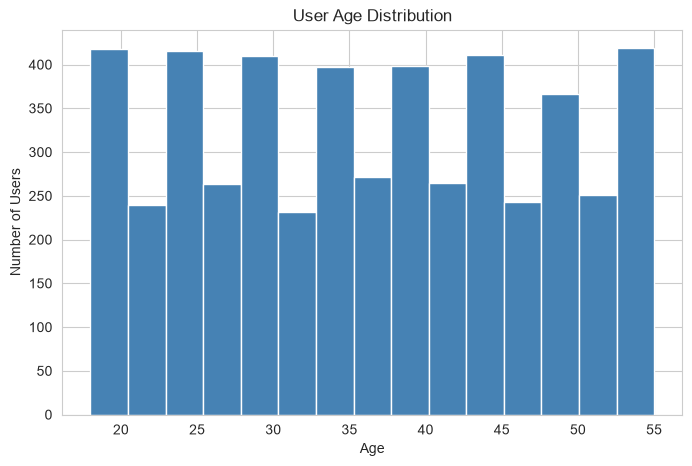

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(users["age"], bins=15, color="steelblue", edgecolor="white")
plt.title("User Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.show()

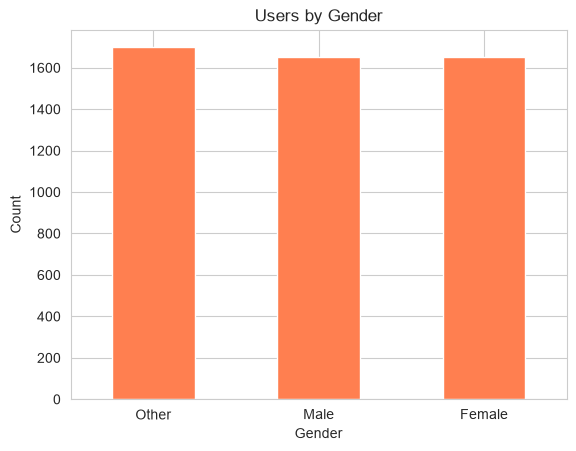

In [18]:
users["gender"].value_counts().plot.bar(color="coral")
plt.title("Users by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

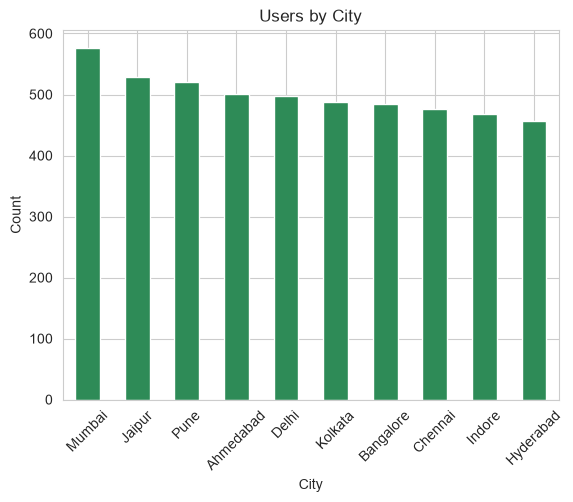

In [19]:
users["city"].value_counts().plot.bar(color="seagreen")
plt.title("Users by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

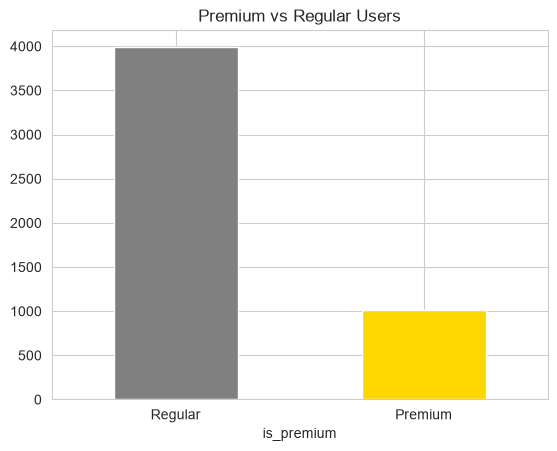

In [20]:
users["is_premium"].value_counts().rename({0: "Regular", 1: "Premium"}).plot.bar(color=["gray", "gold"])
plt.title("Premium vs Regular Users")
plt.xticks(rotation=0)
plt.show()

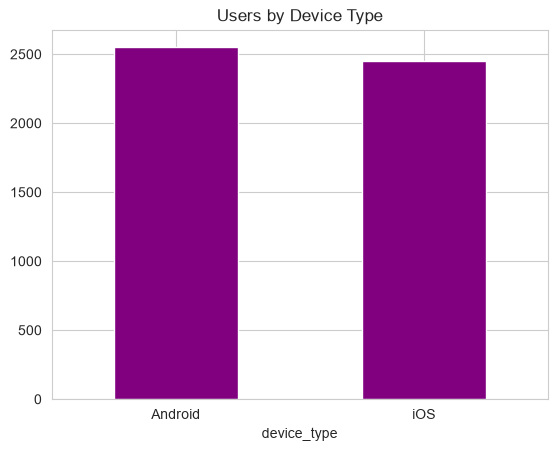

In [21]:
users["device_type"].value_counts().plot.bar(color="purple")
plt.title("Users by Device Type")
plt.xticks(rotation=0)
plt.show()